In [1]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 20.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 67.8 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.9/321.9 kB 56.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 86.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 34.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 55.3 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install s3fs

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 kB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.0/201.0 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 44.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.7/81.7 kB 18.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
boto3 1.40.13 requires botocore<1.41.0,>=1.40.13, but you have botocore 1.41.5 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


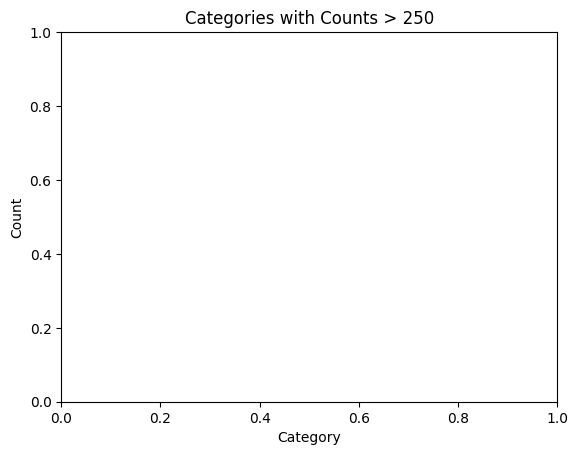

<ipython-input-1-a6d24e3b6e4f>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Rating Range'] = pd.cut(filtered_df['Rating'], bins=[r[0] for r in rating_ranges] + [rating_ranges[-1][-1]], labels=[f'{r[0]}-{r[-1]}'


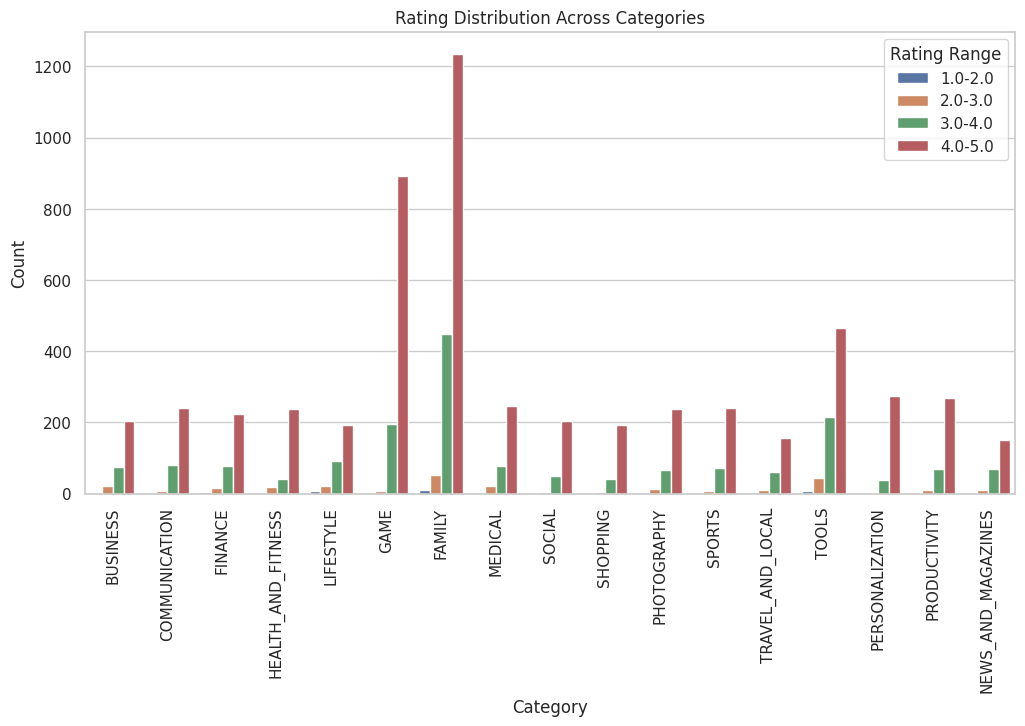

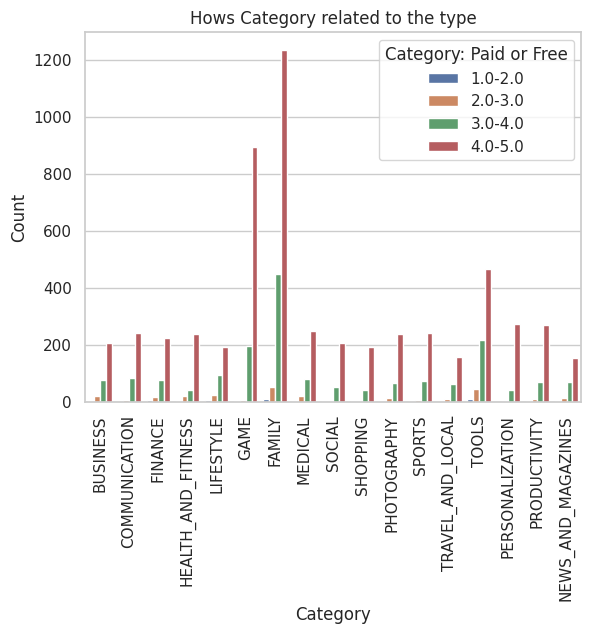

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import s3fs

df = pd.read_csv('s3://mi-emr-studio-pacopedrosaarjona/archive/googleplaystore.csv')
df.sample(10)
df.info()
df.describe()

selected_categories = df['Category'].value_counts()[df['Category'].value_counts() > 250].index

filtered_df = df[df['Category'].isin(selected_categories)]
plt.title('Categories with Counts > 250')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()


rating_ranges = [(1.0, 2.0), (2.0, 3.0), (3.0, 4.0), (4.0, 5.0)]
filtered_df['Rating Range'] = pd.cut(filtered_df['Rating'], bins=[r[0] for r in rating_ranges] + [rating_ranges[-1][-1]], labels=[f'{r[0]}-{r[-1]}'
for r in rating_ranges])

sns.set(style="whitegrid")

plt.figure(figsize=(12,6))
sns.countplot(data=filtered_df, x='Category', hue='Rating Range')
plt.title('Rating Distribution Across Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend(title='Rating Range')
plt.xticks(rotation=90)
plt.show()
sns.countplot(data=filtered_df, x='Category', hue='Rating Range')
plt.title('Hows Category related to the type')
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend(title='Category: Paid or Free')
plt.xticks(rotation=90)
plt.show()


